=========================== Impact Of AI ON Students ============================

# 📊 Executive Summary: The Impact of GenAI on Students

This project analyzes a dataset of 50,000 student records to evaluate how Generative AI utilization correlates with GPA improvements across different academic disciplines. 

## 🔍 Key Discoveries at a Glance:
* The Major Showdown Winner:** **STEM students** achieved the highest academic return on investment, with a top-performing average GPA increase of **+0.218**.
* Universal Academic Equalizer:** While STEM led the pack, performance gains were remarkably balanced across campus—with Medical (+0.208), Humanities (+0.206), Arts (+0.205), and Business (+0.202) all showing consistent, stable growth. 
* Overall Academic Lift:** On average, across all majors and categories, students using GenAI tools realized an approximate **+0.20 GPA improvement** over the semester.
* Usage Patterns:** Weekly usage distribution is heavily **right-skewed**, indicating that the vast majority of students are casual users (0-8 hours), while a small segment of power users drives the upper limit.

---
## 💻 Step-by-Step Data Analysis Workflow
*(The technical data cleaning, exploration, and verification code continue below)*

In [8]:
import numpy as np
import pandas as pd

In [12]:
import os

if os.path.exists("my_dataset.csv"):
    print("Found it!")
else:
    print("File isn't there.")

File isn't there.


In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

print("Path to dataset files:", path)

Path to dataset files: /Users/naitikpatidar/.cache/kagglehub/datasets/laveshjadon/ai-impact-on-students/versions/1


In [13]:
import os
import pandas as pd

# 1. Get a list of all files inside your downloaded Kaggle folder
files = os.listdir(path)

# 2. Find the file that ends with .csv
csv_file_name = [f for f in files if f.endswith('.csv')][0]

# 3. Safely combine the folder path and the file name
full_csv_path = os.path.join(path, csv_file_name)

# 4. Load it into a pandas DataFrame
df = pd.read_csv(full_csv_path)

# 5. Print the columns and show the first few rows
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [16]:
import os

# 1. Grab all files in the directory
files = os.listdir(path)

# 2. Extract the actual name of the CSV file dynamically
csv_file_name = [f for f in files if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_file_name)

# 3. Load and immediately display the dataset
df = pd.read_csv(full_csv_path)
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [19]:
df.head(100)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,100096,Humanities,Senior,3.773,5.21,Copywriting/Drafting,Beginner,1,False,11.81,1,Allowed_With_Citation,3,3.873,59.56,High
96,100097,Business,Freshman,2.907,3.32,Direct_Answer_Generation,Intermediate,2,False,8.40,2,Actively_Encouraged,5,2.993,71.80,Medium
97,100098,Humanities,Graduate,2.292,3.02,Copywriting/Drafting,Beginner,2,False,9.14,2,Allowed_With_Citation,3,2.918,66.73,Medium
98,100099,STEM,Freshman,2.016,28.71,Debugging/Troubleshooting,Advanced,5,True,5.64,6,Allowed_With_Citation,4,2.473,55.74,Medium


In [18]:
# Check the exact dimensions of your data (rows, columns)
print(df.shape)

(50000, 16)


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [30]:
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [42]:
df.loc[df["Weekly_GenAI_Hours"].sort_values(ascending=False).head(10).index]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
31588,131589,Business,Junior,3.906,40.0,Ideation,Beginner,3,True,10.60,10,Actively_Encouraged,8,4.000,77.55,High
18078,118079,STEM,Junior,1.431,40.0,Direct_Answer_Generation,Beginner,1,True,8.95,9,Strict_Ban,9,1.000,10.78,High
16809,116810,STEM,Senior,2.342,40.0,Debugging/Troubleshooting,Advanced,3,True,1.45,8,Allowed_With_Citation,7,2.751,74.53,High
16793,116794,Business,Sophomore,2.649,40.0,Ideation,Intermediate,2,True,7.19,7,Allowed_With_Citation,2,2.767,49.87,High
49045,149046,STEM,Sophomore,2.645,40.0,Debugging/Troubleshooting,Beginner,2,True,11.68,9,Allowed_With_Citation,6,2.792,72.80,High
26270,126271,STEM,Freshman,3.085,40.0,Ideation,Intermediate,3,True,6.02,6,Allowed_With_Citation,3,3.474,59.51,High
37633,137634,STEM,Senior,3.394,40.0,Debugging/Troubleshooting,Advanced,3,True,6.48,6,Allowed_With_Citation,6,3.876,78.82,High
1335,101336,Business,Graduate,3.069,40.0,Ideation,Beginner,2,True,5.18,6,Actively_Encouraged,2,3.181,82.61,High
49024,149025,STEM,Sophomore,3.666,40.0,Debugging/Troubleshooting,Intermediate,4,True,13.17,9,Allowed_With_Citation,4,4.000,71.17,Medium
37713,137714,STEM,Graduate,3.499,40.0,Debugging/Troubleshooting,Advanced,3,True,1.00,10,Allowed_With_Citation,6,4.000,99.15,High


In [46]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [49]:
weekly_hours = df.loc[df["Weekly_GenAI_Hours"]> 20 ].sort_values(by="Weekly_GenAI_Hours", ascending = False)
weekly_hours

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
16809,116810,STEM,Senior,2.342,40.00,Debugging/Troubleshooting,Advanced,3,True,1.45,8,Allowed_With_Citation,7,2.751,74.53,High
15903,115904,STEM,Graduate,3.687,40.00,Debugging/Troubleshooting,Beginner,3,True,8.47,9,Strict_Ban,10,3.810,49.81,High
46745,146746,STEM,Sophomore,3.091,40.00,Debugging/Troubleshooting,Advanced,5,False,13.24,8,Strict_Ban,10,3.628,83.42,High
44491,144492,STEM,Graduate,3.441,40.00,Debugging/Troubleshooting,Advanced,5,True,13.59,9,Actively_Encouraged,7,4.000,74.88,High
32560,132561,STEM,Sophomore,3.650,40.00,Copywriting/Drafting,Intermediate,5,True,8.26,10,Allowed_With_Citation,6,3.720,71.48,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48515,148516,Humanities,Senior,2.732,20.01,Copywriting/Drafting,Beginner,3,True,13.00,6,Allowed_With_Citation,6,3.153,63.87,High
21827,121828,Business,Sophomore,3.637,20.01,Ideation,Beginner,3,True,8.97,5,Actively_Encouraged,5,3.746,69.01,High
14824,114825,Humanities,Junior,3.457,20.01,Copywriting/Drafting,Intermediate,4,False,1.67,7,Actively_Encouraged,6,3.343,62.23,High
40413,140414,Medical,Graduate,3.676,20.01,Direct_Answer_Generation,Advanced,3,True,21.14,6,Allowed_With_Citation,7,3.786,78.17,High


## high burnout risk individual who use more theb 20 hr/ week AI tools.

In [58]:
df.loc[(df["Burnout_Risk_Level"]== "High") & (df["Weekly_GenAI_Hours"] > 20)]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
27,100028,Business,Junior,3.302,23.96,Ideation,Intermediate,2,True,6.54,5,Allowed_With_Citation,1,3.487,67.74,High
55,100056,Medical,Senior,3.429,20.48,Direct_Answer_Generation,Beginner,2,True,4.24,6,Actively_Encouraged,2,3.521,63.38,High
89,100090,Humanities,Graduate,3.544,34.00,Debugging/Troubleshooting,Beginner,2,False,8.67,6,Actively_Encouraged,1,3.795,68.80,High
100,100101,STEM,Sophomore,3.612,25.83,Debugging/Troubleshooting,Intermediate,3,True,10.46,7,Allowed_With_Citation,6,3.715,62.30,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49975,149976,Business,Graduate,1.915,22.75,Copywriting/Drafting,Intermediate,3,True,6.10,4,Allowed_With_Citation,6,2.159,48.98,High
49980,149981,STEM,Graduate,3.419,25.47,Summarizing_Reading,Advanced,4,True,14.24,6,Allowed_With_Citation,7,3.879,66.16,High
49986,149987,Business,Graduate,3.551,30.07,Debugging/Troubleshooting,Beginner,1,False,6.64,9,Actively_Encouraged,5,3.797,78.28,High
49989,149990,Business,Sophomore,3.113,22.66,Ideation,Intermediate,3,True,15.54,4,Actively_Encouraged,6,3.521,96.06,High


#7.44% student who use AI more then 20 hr / week have high risk of burnout

## NET MEAN SO THAT WE DETERMINE THE ALL OVER IMPACT OF AI ON GRADE.

In [97]:
pre_mean = df["Pre_Semester_GPA"].mean()

In [96]:
post_mean = df["Post_Semester_GPA"].mean()

In [72]:
Net_increase = post_mean - pre_mean
Net_increase

np.float64(0.20319708000000025)

In [73]:
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


## Student who use for what AI.

In [76]:
student_use_for_debugging = df.loc[df["Primary_Use_Case"] == "Debugging/Troubleshooting"]

In [77]:
student_use_for_debugging

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High
15,100016,STEM,Senior,2.076,14.74,Debugging/Troubleshooting,Beginner,1,True,12.59,4,Allowed_With_Citation,4,2.228,70.66,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49986,149987,Business,Graduate,3.551,30.07,Debugging/Troubleshooting,Beginner,1,False,6.64,9,Actively_Encouraged,5,3.797,78.28,High
49988,149989,STEM,Sophomore,2.058,3.32,Debugging/Troubleshooting,Beginner,1,False,6.34,4,Actively_Encouraged,4,2.147,68.75,Low
49992,149993,Business,Graduate,2.829,2.59,Debugging/Troubleshooting,Advanced,3,True,7.54,1,Allowed_With_Citation,4,3.176,84.04,Low
49993,149994,STEM,Sophomore,3.588,25.64,Debugging/Troubleshooting,Intermediate,3,True,4.62,5,Strict_Ban,10,3.841,58.44,High


In [84]:
student_use_for_copywriting = df.loc[df["Primary_Use_Case"] == "Copywriting/Drafting"]

In [85]:
student_use_for_copywriting 

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
12,100013,Arts,Senior,3.479,2.86,Copywriting/Drafting,Beginner,2,False,8.95,2,Actively_Encouraged,4,3.612,67.68,High
14,100015,STEM,Freshman,3.202,1.22,Copywriting/Drafting,Beginner,1,False,16.52,2,Allowed_With_Citation,4,3.122,70.70,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49985,149986,Humanities,Sophomore,3.661,1.91,Copywriting/Drafting,Beginner,3,True,14.19,3,Actively_Encouraged,2,3.910,84.82,Low
49991,149992,Humanities,Freshman,2.708,13.34,Copywriting/Drafting,Intermediate,2,False,11.65,4,Allowed_With_Citation,5,2.785,65.24,High
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium


In [89]:
df["Primary_Use_Case"].value_counts()

Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

                       ## Therir grade in both cases. ##

# 1st case

In [95]:
student_use_for_debugging["Pre_Semester_GPA"].mean()

np.float64(3.1467118340788938)

In [98]:
student_use_for_debugging["Post_Semester_GPA"].mean()

np.float64(3.395839528263522)

# 2nd case

In [99]:
student_use_for_CopywritingAndDrafting["Pre_Semester_GPA"].mean()

np.float64(3.134880276413288)

In [100]:
student_use_for_CopywritingAndDrafting["Post_Semester_GPA"].mean()

np.float64(3.3353059695279326)

For student who use ai for debugging has 0.25 growth in their GPA.
For student who use ai for copy writhin has 0.21 growth in their GPA.


In [101]:
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [ ]:
# Counting how many of students uses paid tools.

In [102]:
df["Paid_Subscription"].value_counts()

Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64

#IN this data set its 42.308% uses paid tools. 

# Skill of uging AI basically Prompt Engineering.

In [131]:
df[df["Prompt_Engineering_Skill"] == "Beginner"].value_counts()

Student_ID  Major_Category  Year_of_Study  Pre_Semester_GPA  Weekly_GenAI_Hours  Primary_Use_Case           Prompt_Engineering_Skill  Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  Perceived_AI_Dependency  Institutional_Policy   Anxiety_Level_During_Exams  Post_Semester_GPA  Skill_Retention_Score  Burnout_Risk_Level
100001      Humanities      Senior         2.418             23.31               Copywriting/Drafting       Beginner                  1               True               8.13                     5                        Allowed_With_Citation  6                           2.393              86.44                  High                  1
100003      Business        Freshman       3.398             21.26               Summarizing_Reading        Beginner                  2               False              10.35                    5                        Strict_Ban             9                           3.499              73.93                  Medium               

Almost 36.99% Students are at Beginner level skill.

# Intermediate level

In [130]:
df[df["Prompt_Engineering_Skill"] == "Intermediate"].value_counts()

Student_ID  Major_Category  Year_of_Study  Pre_Semester_GPA  Weekly_GenAI_Hours  Primary_Use_Case           Prompt_Engineering_Skill  Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  Perceived_AI_Dependency  Institutional_Policy   Anxiety_Level_During_Exams  Post_Semester_GPA  Skill_Retention_Score  Burnout_Risk_Level
100004      Business        Senior         3.789             1.82                Copywriting/Drafting       Intermediate              4               False              15.23                    2                        Allowed_With_Citation  2                           4.000              63.58                  Medium                1
100008      Arts            Junior         2.746             5.33                Copywriting/Drafting       Intermediate              3               False              18.45                    2                        Actively_Encouraged    1                           2.965              85.09                  Medium               

Almost 35.392% Students are at Intermediate level skill.

In [125]:
df[df["Prompt_Engineering_Skill"] == "Advanced"].value_counts()

Student_ID  Major_Category  Year_of_Study  Pre_Semester_GPA  Weekly_GenAI_Hours  Primary_Use_Case           Prompt_Engineering_Skill  Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  Perceived_AI_Dependency  Institutional_Policy   Anxiety_Level_During_Exams  Post_Semester_GPA  Skill_Retention_Score  Burnout_Risk_Level
100002      Medical         Junior         3.821             1.12                Ideation                   Advanced                  5               False              16.65                    3                        Allowed_With_Citation  9                           3.696              69.39                  Low                   1
100005      STEM            Sophomore      3.635             9.29                Debugging/Troubleshooting  Advanced                  4               False              12.55                    4                        Allowed_With_Citation  4                           3.798              100.00                 Medium               

Almost 27.618% Students are at Advance level skill.

In [121]:
 df["Prompt_Engineering_Skill"].value_counts

<bound method IndexOpsMixin.value_counts of 0            Beginner
1            Advanced
2            Beginner
3        Intermediate
4            Advanced
             ...     
49995        Beginner
49996    Intermediate
49997        Advanced
49998    Intermediate
49999        Beginner
Name: Prompt_Engineering_Skill, Length: 50000, dtype: str>

/var/folders/2g/vcqv7bvn1xq6yxx44z_fdbr40000gn/T/ipykernel_21498/1320579541.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_percentages.index, y=skill_percentages.values, palette="Blues_r")


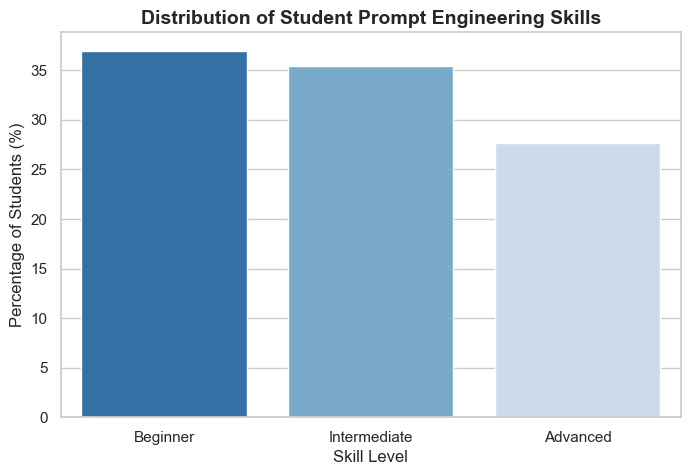

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Create the bar plot
sns.barplot(x=skill_percentages.index, y=skill_percentages.values, palette="Blues_r")

# Add labels and title
plt.title("Distribution of Student Prompt Engineering Skills", fontsize=14, fontweight='bold')
plt.xlabel("Skill Level", fontsize=12)
plt.ylabel("Percentage of Students (%)", fontsize=12)

# Show the plot
plt.show()

##### Analyzing ho weekly AI hour spread out across all student

In [132]:
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [133]:
df["Weekly_GenAI_Hours"].mean()

np.float64(8.4277522)

In [134]:
df["Weekly_GenAI_Hours"].median()

np.float64(5.8)

In [158]:
df["Weekly_GenAI_Hours"].between(0, 8).sum()
print("Number of students using GenAI between  0 and 8 hours per week:", df["Weekly_GenAI_Hours"].between(0, 8).sum())

Number of students using GenAI between  0 and 8 hours per week: 30762


In [151]:
df[df["Weekly_GenAI_Hours"] >= 25].shape[0]
print("Number of students using GenAI 25 or more hours per week:", df[df["Weekly_GenAI_Hours"] >= 25].shape[0])

Number of students using GenAI 25 or more hours per week: 2822


In [154]:
df["Weekly_GenAI_Hours"].between(9, 25).sum()
print("Number of students using GenAI between 9 and 25 hours per week:", df["Weekly_GenAI_Hours"].between(9, 25).sum())

Number of students using GenAI between 9 and 25 hours per week: 14374


# Which major gets the biggest grade boost from using AI? Lets See

In [160]:
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [161]:
df["Major_Category"].value_counts()

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

In [ ]:
#STEM_GPA1 = df[df["Major_Category"]== "STEM"] ["Pre_Semester_GPA"].mean()

np.float64(3.14585184939239)

In [ ]:
#STEM_GPA2 = df[df["Major_Category"]== "STEM"] ["Post_Semester_GPA"].mean()


np.float64(3.363154127100073)

In [176]:
#net_STEM_GPA_increase = STEM_GPA2 - STEM_GPA1

In [175]:
# Group by major and calculate the average pre and post GPAs
major_gpa = df.groupby("Major_Category")[["Pre_Semester_GPA", "Post_Semester_GPA"]].mean()


major_gpa["GPA_Jump"] = major_gpa["Post_Semester_GPA"] - major_gpa["Pre_Semester_GPA"]


print(major_gpa)

                Pre_Semester_GPA  Post_Semester_GPA  GPA_Jump
Major_Category                                               
Arts                    3.146786           3.343688  0.196902
Business                3.141760           3.336085  0.194325
Humanities              3.147850           3.345825  0.197976
Medical                 3.151769           3.353168  0.201399
STEM                    3.145852           3.363154  0.217302
